In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math 


import mesa
from mesa.datacollection import DataCollector
from mesa import Model
from mesa.space import MultiGrid
from mesa.experimental.cell_space import CellAgent, FixedAgent, OrthogonalVonNeumannGrid
from mesa.experimental.devs import ABMSimulator
from mesa.visualization import Slider, SolaraViz, make_plot_component, make_space_component


In [113]:
#this cell is used for the base class of bronchial
class Bronchial(FixedAgent):
    def __init__(self, model, pos, init_health =100): #put in all the baseline values we want,
        super().__init__(model)
        self.init_health = init_health #initial health of bronchial
        self.health = init_health
        self.pos = pos 
        #self.schedule_event(self.replacement, at=7.0)
    #def placement(self):
        
    #healing rate mechanism 
    def healing(self):
        for obj in self.cell.neighborhood:
            bound_bacteria=False
            for obj in cell.agents:
                if isinstance(obj,Pathogen):
                    bound_bacteria=True
                    break
        if (bound_bacteria==False) and (self.health<(self.init_health/2)):
            self.health+=1    
            
    #replenisment rate mechanism
    def replacement(self):
        #find how long it takes to replace itself
        for cell in self.cell.neighborhood: #looks at all the neighbooring cells
            bound_bacteria=False
            for obj in cell.agents: #looks at all the agents in a cell like they were a list
                if isinstance(obj,Pathogen):
                    bound_bacteria=True
                    break
        if (bound_bacteria==False) and self.health>(self.init_health*.75):
            self.new_pos = (self.pos[0]+1,self.pos[1])
            self.__class__(self.model,self.cell,self.health,self.new_pos)
        
    def call_macro(self): #function to call macrophages from bloodstream in cell injury
        for obj in cell.agents:
            if self.init_health > 75: #note this is a temporary thing to see if the code is working, idk if itll stay init or not and the sign should be flipped
                new_macro = Macrophage(Macrophage.pos, Macrophage.cell, Macrophage.health, Macrophage.strength, Macrophage.macrophage_gain, Macrophage.p_rep)
                x = self.random.randrange(self.grid.width)
                y = self.random.randrange(2)
                Macrophage.model.place_agent(new_macro, (x,y))
    
    #what happens each step
    def step(self):
        return
        #if health <= 0: #cell death
            #self.remove()
        #elif health <= #value for it to trigger healing? which in turns calls mucus:
        #self.call_macro()  

In [114]:
#this cell is used for the base class of the bacteria and biofilm

class Pathogen(CellAgent):
    def __init__(self, model, pos, cell, health = 100, strength = 10, bacteria_gain= 10, p_rep = 0.04, p_unstick = 0.04, biof_formed = False):
        super().__init__(model)
        self.pos = pos
        self.cell = cell
        self.health = health #lifespan of pathogen
        self.strength = strength #how much damage it deals to brocnhial
        self.bacteria_gain = bacteria_gain #how much "health" bacteria gains from bronchiol damage
        self.p_rep = p_rep #probability to trigger reproduction
        self.p_unstick = p_unstick #probability of bacteria in biofilm to "unstick" from biofilm
        self.biof_formed = biof_formed #if the specific bacteria is part of the biofilm or not

    
    #movement - random, limited by mucus, but evasion of macrophages 
    def move_bacteria(self):
        self.model.grid.move_agent(self, (self.pos[0],self.pos[1]+1))

    #damaging the bronchiol - cell loses healt, brionchial gains health 
    def atk_bacteria(self):
        return
        bronchiol_present = lambda cell: any(isinstance(obj, Bronchial) for obj in cell.agent)
        if bronchiol_present.available:
            self.health += bacteria_gain
            Bronchial.health -=self.strength
            #

        
    #biofilm formation upon contact with other bacteria
    def biofilm_formation(self):
        return
        #idea before implementation - model biofilm by just makeing them stick to each other and then increasing the health by a certain ffactor when x amount is present and maybe
        #we can also model it to have a certain step strength in a random direction that will decrease the more are connected? and we can have antibiotic deal damage exactly as large as the health or say it insta kills it vs deald this mich dMG when not insta kill
        #model prob of unstick with liek if random is (p sunstick then it will detach)
        bacteria_present = lambda cell: any(isinstance(obj, Pathogen)for obj in cell.agent)

        #code to model bacteria stikcing together in biofilm
        if bacteria.present.available and (self.biof_formed == False):
            #insert code here lol
            self.biof_formed = True

        #probability of bacteria to stop sticking to biofilm
        if (self.biof_formed== True) and (self.random.random() < self.p_unstick):
            #insert code here lol
            self.biof_formed = False

            


    #reproduction rate of bacteria
    def spawn_offspring(self):
        #using half of its health, it can spawn offspring
        self.health /= 2
        new_bac= Pathogen(self.model, self.pos, self.cell,self.health, self.bacteria_gain, p_rep)
        self.model.grid.place_agent(new_bac, self.pos)
        

    #what happens each step
    def step_bacteria(self):
        self.move_bacteria()
        self.biofilm_formation()
        self.atk_bacteria()
        #bacterial death or reproduction
        if self.health < 0:
            return
            #self.remove()
        elif self.random.random() < self.p_rep :    
            self.spawn_offspring()
        
                 

In [115]:
#this cell is used for the base class of the mucus
class Mucin(CellAgent):
    def __init__(self, model, pos, cell = None):
        super().__init__(model)
        self.pos = pos
        self.cell = cell
    #mucus acts as a medium for the antibiotics, pathogens, and macrophages to travel

    
    #production of mucins from bottom layer of mucus 
    def production(self): #split into 4 types or 3 types of production based on severity
        #get information on status of brionchial
        neighbor = self.model.grid.get_neighbors(self.pos, False)
        for obj in neighbor:# mucin is not being placed as agent
            if isinstance(obj,Bronchial): #im thinking that to time things create different def for each type of production caus ethe conditional only worked in step
                if obj.health > 75: #first injury secretion
                    new_mu = Mucin(self.model, self.pos, self.cell)
                    self.model.grid.place_agent(new_mu, self.pos)


                elif obj.health < 50: #increased secretion
                    self.__class__(self.model, self.pos, self.cell)
                    self.__class__(self.model, self.pos, self.cell)

                elif obj.health < 25: #max secretion
                    self.__class__(self.model)
                    self.__class__(self.model)
                    self.__class__(self.model)

        #ensure mucus is in one layer
        neighborm = self.model.grid.get_neighbors(self.pos, False,include_center = True, radius = 0)
        mucus_positioning = any(isinstance(obj, Mucin) for obj in neighborm)
        #while mucus_positioning

        self.model.grid.move_agent(self, (self.pos[0],self.pos[1]+1)) # it is moving up regarless of if there is a u cin
        mucus_positioning = any(isinstance(obj, Mucin) for obj in neighborm)


    #movement of mucus through cilia
    def move_cilia(self):
        #idea for this specific string of code is to remove itself if it is at the boundary, i think theres a way to do it with reference to how i did the model spawning code
        #each step it will move ____(1), and remove those past bc
        self.model.grid.move_agent(self, (self.pos[0]-1,self.pos[1]))
    #     if self.is_at_boundary():
    #         self.model.grid.remove_agent(self) # this is the specific code that wouldnt work, it might be the if statement
        #cilia_mu = Mucin(self.model, self.pos, self.cell)
    

        #after cilia pushes, muscin will try to spread out randomly/ normal level muscin will replenish
        #insert code for random 2d movemtn
        #boundary past = .remove


        #note that we also need to add code here that spanws the mucin either here or up in prodcution (spawns on the very right, as in cilia is pushin it into the model?)

    #clearance of mucus through cough - fix oth movements to moveout and get deletdtt
    def move_cough(self):
        #define how much "agents" get moved in one cough, needs same clearance boundaries as move cilia
        if self.model.random.random() < 0.5:
            
            self.model.grid.move_agent(self, (self.pos[0]-2, self.pos[1]))

    #mucus thinner properties initialized here as timestop of mucus viscosity(???_)

    #what happens each step
    def step(self):
        #movement of mucus
        self.move_cilia()
        self.move_cough()
        if self.model.step_count%2==0:
            self.production()

In [116]:
#this cell is used for the base class of the macrophage
class Macrophage(CellAgent):
    def __init__(self, model, pos, cell=None, health = 20,strength = 20, macrophage_gain= 15, p_rep = 0.04):
        super().__init__(model)
        self.pos = pos
        self.cell = cell
        self.health = health
        self.strength = strength
        self.macrophage_gain = macrophage_gain
        self.p_rep = p_rep
    
    #movement - aims for the bacteria 
    def move_macrophage(self):
        #macrophage will move within mucin
        pathogen_found = self.cell.neighborhood.select(
            lambda cell: any(isinstance(obj, Salmonella) for obj in cell.agents)
        )
        #do we want random movement? if yes, i think this needs to go in a diff if, else line
        target_pathogen = pathogen_found if len(pathogen_found) > 0 else self.cell.neighborhood
        self.cell = target_pathogen.select_random_cell()

    def spawn_rep(self): #mechanism for macrophages to increase through replication
        pass


        
    #what happens each step
    def step(self):
        #self.move_macrophage()
        self.health -=1 #will moving and cntact decrease health?
        #remove when health is 0
        #reproduction mechanism

In [117]:
#this cell is used for the base class of antibiotics
class Antibiotic(CellAgent):
    def __init__(self, model,pos, health = 15, strength = 10,):
        super().__init__(model)
        self.pos = pos
        self.health = health
        self.strength = strength
    
    def move_anti(self):
        pass
    
    def step(self):
        self.move_anti()
        self.health -= 1 #in this case this is how long it lasts in the body
        #cell remobe here when health is gone
        #reproduction mechanism

In [122]:
#this cell is used for the creation of the model, which creates the grid
class LungModel(Model):
    def __init__(self, width=20, height=20, init_health_Bronchial=100, seed=100, simulator=None):
        super().__init__(seed=seed)
        self.simulator = simulator
        self.simulator.setup(self)
        self.grid = MultiGrid(width, height, torus=True)
        self.step_count=0
        reporters = {
            "Mucin": lambda m: len(m.agents_by_type[Mucin]),
            "Bronchial": lambda m: len(m.agents_by_type[Bronchial]),
            "Pathogen": lambda m: len(m.agents_by_type[Pathogen]),
            "Antibiotic": lambda m: len(m.agents_by_type[Antibiotic]),
            "Macrophage": lambda m: len(m.agents_by_type[Macrophage])

        }
        self.datacollector = DataCollector(reporters)


#set the fixed position of the bronchial layer
        for x in range(width):
            epithelial=Bronchial(
                self,
                (x,2),
                init_health = init_health_Bronchial,
                ) #makes 20 of the bronchial, the ali form makes batches of randomly placed
            self.grid.place_agent(epithelial, (x,2))
        self.total_mucin = 0

        while self.total_mucin != 100:
            for y in range(3,5):
                x = self.random.randrange(self.grid.width)
                mucus_layer= Mucin(self,(x,y),cell= None,) #ramdon placement within first line
                self.grid.place_agent(mucus_layer,(x,y))
                self.total_mucin+=1

        
        total_bact = 0
        total_macro = 0
        while total_bact != 10 : #code to spawn the bacteria within bounds of mucus
            x = self.random.randrange(self.grid.width)
            y = self.random.randrange(self.grid.height)
            if any(isinstance(agent, Mucin) for agent in self.grid[x][y]):
                total_bact+=1
                bacteria = Pathogen(
                    self,
                    cell =None,
                    pos = (x,y),
                    health = 100,
                    strength = 10,
                    bacteria_gain= 10,
                    p_rep = 0.04,
                    p_unstick = 0.04,
                    biof_formed = False,
                    )
                self.grid.place_agent(bacteria, (x,y))

        while total_macro != 5 : #code to spawn the macro within bounds of mucus
            x = self.random.randrange(self.grid.width)
            y = self.random.randrange(self.grid.height)
            if any(isinstance(agent, Mucin) for agent in self.grid[x][y]):
                total_macro+=1
                macrophages = Macrophage(
                    self,
                    cell = None,
                    pos = (x,y),
                    health = 20,
                    strength = 20,
                    macrophage_gain = 15,
                    p_rep = 0.04,
                    )
                self.grid.place_agent(macrophages, (x,y))       
        
        for x in range(width):
            antibiotic = Antibiotic(
                self,
                (x,1),
                health = 15,
                strength= 10,
                )
            self.grid.place_agent(antibiotic, (x,1))


# think abt bc for stopping mucus at bronchior

#set the initial position of antibiotics


    def step(self):
        self.step_count+=1
        self.agents_by_type[Bronchial].shuffle_do("step")
        self.agents_by_type[Mucin].shuffle_do("step")
        self.agents_by_type[Pathogen].shuffle_do("step")
        self.agents_by_type[Antibiotic].shuffle_do("step")
        self.agents_by_type[Macrophage].shuffle_do("step")
        self.datacollector.collect(self)



In [123]:
# Styling for visualization
AGENT_COLORS = {
    "Bronchial": "#FD7D7B",
    "Mucin": "green",
    "Pathogen": "blue",
    "Antibiotic": "black",
    "Macrophage": "purple"
}

# Change these parameters to experiment with the model!
MODEL_PARAMETERS = {
    "width": 20, # Grid width
    "height": 20, # Grid height
    #this is wher eu would put the parameter s(if we had any)
    "bronchial_init_health": 100, # heaalth of bironchil
    "seed": 100, # Random seed for reproducibility
}
def lung_portrayal(agent):
    if agent is None:
        return
    p = {"size": 25}
    if isinstance(agent, Mucin):
        p.update({"color": AGENT_COLORS["Mucin"], "marker": "o", "zorder": 3, "size": 45}) #zorder = positioning of whihc is the tip layer
    elif isinstance(agent, Bronchial):
        p.update({"color": AGENT_COLORS["Bronchial"], "marker": "o", "zorder": 60})
    elif isinstance(agent, Pathogen):
        p.update({"color": AGENT_COLORS["Pathogen"], "marker": "o", "zorder": 4, "size" : 25})
    elif isinstance(agent, Antibiotic):
        p.update({"color": AGENT_COLORS["Antibiotic"], "marker": "o", "zorder": 4, "size" : 25})
    elif isinstance(agent, Macrophage):
        p.update({"color": AGENT_COLORS["Macrophage"], "marker": "o", "zorder": 4, "size" : 25})

    return p

model_params = {
    "width": 20,
    "height": 20,
    "bronchial_init_health": Slider("Initial Health of Bronchiol", MODEL_PARAMETERS["bronchial_init_health"], 10, 300),
}

simulator = ABMSimulator()
model_instance = LungModel(simulator=simulator)
space_component = make_space_component(lung_portrayal, draw_grid=True)
lineplot_component = make_plot_component({
    "Bronchial": AGENT_COLORS["Bronchial"],
    "Mucin": AGENT_COLORS["Mucin"],
    "Pathogen": AGENT_COLORS["Pathogen"],
    "Antibiotic": AGENT_COLORS["Antibiotic"],
    "Macrophage": AGENT_COLORS["Macrophage"]
})

page = SolaraViz(
    model_instance,
    components=[space_component, lineplot_component],
    model_params=model_params,
    simulator=simulator,
)
page



/tmp/ipykernel_1146/490193454.py:27: UserWarning: Agent 1 is being placed with
place_agent() despite already having the position (0, 2). In most
cases, you'd want to clear the current position with remove_agent()
before placing the agent again.
  self.grid.place_agent(epithelial, (x,2))
/tmp/ipykernel_1146/490193454.py:27: UserWarning: Agent 2 is being placed with
place_agent() despite already having the position (1, 2). In most
cases, you'd want to clear the current position with remove_agent()
before placing the agent again.
  self.grid.place_agent(epithelial, (x,2))
/tmp/ipykernel_1146/490193454.py:27: UserWarning: Agent 3 is being placed with
place_agent() despite already having the position (2, 2). In most
cases, you'd want to clear the current position with remove_agent()
before placing the agent again.
  self.grid.place_agent(epithelial, (x,2))
/tmp/ipykernel_1146/490193454.py:27: UserWarning: Agent 4 is being placed with
place_agent() despite already having the position (3, 2).

Cannot show ipywidgets in text

Running simulation for 10 steps...


/tmp/ipykernel_1146/490193454.py:27: UserWarning: Agent 1 is being placed with
place_agent() despite already having the position (0, 2). In most
cases, you'd want to clear the current position with remove_agent()
before placing the agent again.
  self.grid.place_agent(epithelial, (x,2))
/tmp/ipykernel_1146/490193454.py:27: UserWarning: Agent 2 is being placed with
place_agent() despite already having the position (1, 2). In most
cases, you'd want to clear the current position with remove_agent()
before placing the agent again.
  self.grid.place_agent(epithelial, (x,2))
/tmp/ipykernel_1146/490193454.py:27: UserWarning: Agent 3 is being placed with
place_agent() despite already having the position (2, 2). In most
cases, you'd want to clear the current position with remove_agent()
before placing the agent again.
  self.grid.place_agent(epithelial, (x,2))
/tmp/ipykernel_1146/490193454.py:27: UserWarning: Agent 4 is being placed with
place_agent() despite already having the position (3, 2).

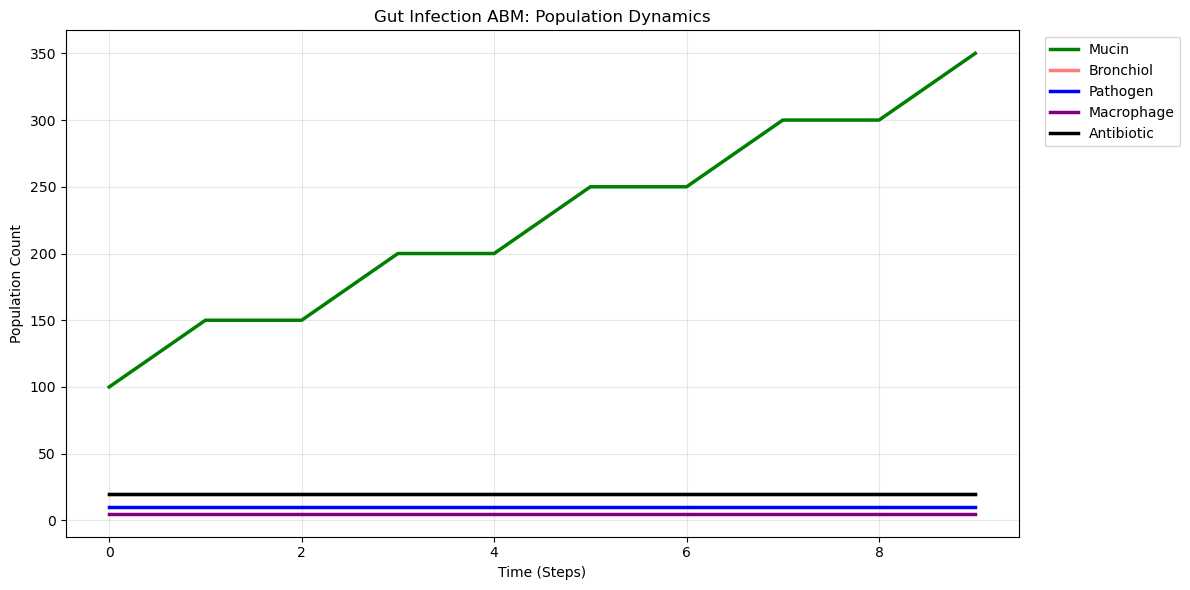

In [124]:
import matplotlib.pyplot as plt

# Change these parameters to experiment with the model!
MODEL_PARAMETERS = {
    "width": 20, # Grid width
    "height": 20, # Grid height
    #this is wher eu would put the parameter s(if we had any)
    "init_health_Bronchial": 100, # heaalth of bironchil
    "seed": 100, # Random seed for reproducibility
}

# Change this value to run the simulation for more or fewer steps
steps_to_run = 10 

print(f"Running simulation for {steps_to_run} steps...")

backup_simulator = ABMSimulator()

# New model instance separate from the one used in the SolaraViz
backup_model = LungModel(
    simulator=backup_simulator,
    **MODEL_PARAMETERS
)

# for _ in range(steps_to_run):
#     backup_model.step()
    
backup_simulator.run_for(steps_to_run)

df = backup_model.datacollector.get_model_vars_dataframe()

plt.figure(figsize=(12, 6))

plt.plot(df.index, df["Mucin"], color=AGENT_COLORS["Mucin"], label="Mucin", linewidth=2.5)
plt.plot(df.index, df["Bronchial"], color=AGENT_COLORS["Bronchial"], label="Bronchiol", linewidth=2.5)
plt.plot(df.index, df["Pathogen"], color=AGENT_COLORS["Pathogen"], label="Pathogen", linewidth=2.5)
plt.plot(df.index, df["Macrophage"], color=AGENT_COLORS["Macrophage"], label="Macrophage", linewidth=2.5)
plt.plot(df.index, df["Antibiotic"], color=AGENT_COLORS["Antibiotic"], label="Antibiotic", linewidth=2.5)


# Formatting
plt.title("Gut Infection ABM: Population Dynamics")
plt.xlabel("Time (Steps)")
plt.ylabel("Population Count")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1)) # Puts legend outside the plot
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Display the plot
plt.show()

# TIP: To save this image for your PDF, right-click the plot and select "Save image as..."
# Alternatively, uncomment the line below to save it directly to your folder:
# plt.savefig("my_time_series.png", dpi=300)